In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 1. تسطيب برنامج فك الضغط
!apt-get install p7zip-full -y

# 2. إنشاء فولدر مؤقت على كولاب عشان الفيديوهات
!mkdir -p /content/karsl_videos

# 3. فك الضغط للملفات (إذا لم تفعل ذلك مسبقاً)
!7z x "/content/drive/MyDrive/KArSL-502/01/train/0001-0070.7z" -o"/content/karsl_videos/" -aos
!7z x "/content/drive/MyDrive/KArSL-502/01/train/0071-0170.7z" -o"/content/karsl_videos/" -aos
!7z x "/content/drive/MyDrive/KArSL-502/01/train/0171-0190.7z" -o"/content/karsl_videos/" -aos
!7z x "/content/drive/MyDrive/KArSL-502/01/train/0191-0300.7z" -o"/content/karsl_videos/" -aos
!7z x "/content/drive/MyDrive/KArSL-502/01/train/0301-0502.7z" -o"/content/karsl_videos/" -aos

print("✅ تم فك الضغط بنجاح!")

!pip install --upgrade protobuf mediapipe --quiet
!wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
!wget -q -O pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task
print("✅ تم تحميل موديلات MediaPipe")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/KArSL-502/01/train/                                                    1 file, 1655690618 bytes (1579 MiB)

Extracting archive: /content/drive/MyDrive/KArSL-502/01/train/0001-0070.7z
--
Path = /content/drive/MyDrive/KArSL-502/01/train/0001-0070.7z
Type = 7z
Physical Size = 1655690618
Headers Size = 33983
Method = LZMA2:26
Solid = +
Blocks = 1

  0%      0% 104 - 0001/01_01_0001_(17_11_16_16_28_15)_c.mp4

In [3]:
import os
import cv2
import numpy as np
import glob
import json
import time
import math
from sklearn.model_selection import train_test_split
import mediapipe as mp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

print(f"MediaPipe: {mp.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

DRIVE_DATA_PATH = '/content/karsl_videos/'
WORK_DIR = '/content/karsl_project'
EXTRACTED_PATH = os.path.join(WORK_DIR, 'extracted_landmarks')
PROCESSED_PATH = os.path.join(WORK_DIR, 'processed')
MODEL_PATH = os.path.join(WORK_DIR, 'model')

os.makedirs(EXTRACTED_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

SEQUENCE_LENGTH = 30
FEATURES = 258

MediaPipe: 0.10.35
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!unzip -q -o "/content/drive/MyDrive/KArSL_Extracted_Data_Backup.zip" -d "/"
print("✅ تم استرجاع الـ 70 كلمة بنجاح لمساحة العمل!")

✅ تم استرجاع الـ 70 كلمة بنجاح لمساحة العمل!


In [5]:
def find_sign_folders(base_path):
    sign_folders = []
    for root, dirs, files in os.walk(base_path):
        mp4_files = [f for f in files if f.endswith('.mp4') or f.endswith('.avi')]
        if mp4_files:
            sign_id = os.path.basename(root)
            sign_folders.append((sign_id, root, len(mp4_files)))
    sign_folders.sort(key=lambda x: x[0])
    return sign_folders

sign_folders = find_sign_folders(DRIVE_DATA_PATH)
print(f"🔍 تم العثور على {len(sign_folders)} إشارة في الفيديوهات.")

hand_options = vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path='/content/hand_landmarker.task'),
    running_mode=vision.RunningMode.VIDEO, num_hands=2,
    min_hand_detection_confidence=0.4, min_tracking_confidence=0.4
)

pose_options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path='/content/pose_landmarker.task'),
    running_mode=vision.RunningMode.VIDEO,
    min_pose_detection_confidence=0.4, min_tracking_confidence=0.4
)

def extract_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    keypoints_seq = []
    hand_lm = vision.HandLandmarker.create_from_options(hand_options)
    pose_lm = vision.PoseLandmarker.create_from_options(pose_options)
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        if frame_idx % 2 != 0:
            frame_idx += 1; continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        timestamp_ms = int(frame_idx * (1000 / fps))

        try: hand_result = hand_lm.detect_for_video(mp_image, timestamp_ms)
        except: hand_result = None
        try: pose_result = pose_lm.detect_for_video(mp_image, timestamp_ms)
        except: pose_result = None

        rh, lh = np.zeros(63), np.zeros(63)
        if hand_result and hand_result.hand_landmarks:
            for i, (hand_landmarks, handedness) in enumerate(zip(hand_result.hand_landmarks, hand_result.handedness)):
                hand_data = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks]).flatten()
                label = handedness[0].category_name.lower()
                if label == 'right': rh = hand_data
                elif label == 'left': lh = hand_data

        pose = np.zeros(132)
        if pose_result and pose_result.pose_landmarks:
            landmarks = pose_result.pose_landmarks[0]
            pose = np.array([[lm.x, lm.y, lm.z, lm.visibility] for lm in landmarks]).flatten()

        keypoints_seq.append(np.concatenate([rh, lh, pose]))
        frame_idx += 1

    cap.release(); hand_lm.close(); pose_lm.close()
    return np.array(keypoints_seq) if keypoints_seq else None

print("🦴 بدء استخراج Landmarks...")
start = time.time()
total_done, total_errors = 0, 0

for idx, (sign_id, sign_path, num_vids) in enumerate(sign_folders):
    save_dir = os.path.join(EXTRACTED_PATH, sign_id)
    if os.path.exists(save_dir):
        existing = len(glob.glob(os.path.join(save_dir, '*.npy')))
        if existing >= num_vids * 0.8:
            print(f"⏭️ [{idx+1}/{len(sign_folders)}] {sign_id}: موجود بالفعل ({existing} ملف) - سيتم تخطيه.")
            total_done += existing
            continue

    os.makedirs(save_dir, exist_ok=True)
    videos = sorted(glob.glob(os.path.join(sign_path, '*.mp4')) + glob.glob(os.path.join(sign_path, '*.avi')))

    success = 0
    for vi, vf in enumerate(videos):
        try:
            kp = extract_from_video(vf)
            if kp is not None and len(kp) > 0:
                np.save(os.path.join(save_dir, f"{vi:03d}.npy"), kp)
                success += 1
        except Exception as e:
            total_errors += 1

    total_done += success
    elapsed = time.time() - start
    eta = (elapsed / (idx + 1)) * (len(sign_folders) - idx - 1)
    print(f"✅ [{idx+1}/{len(sign_folders)}] {sign_id}: {success}/{len(videos)} | متبقي تقريباً: {eta/60:.0f} دقيقة")

    # حفظ مرحلي كل 20 إشارة (عشان لو فصل منخسرش حاجة)
    if (idx + 1) % 20 == 0:
        print("💾 جاري أخذ نسخة احتياطية مرحلية لتجنب ضياع المجهود...")
        !zip -r -q -u "/content/drive/MyDrive/KArSL_Extracted_Data_Backup.zip" "/content/karsl_project/extracted_landmarks/"

print(f"🎉 اكتمل الاستخراج! الوقت الكلي: {(time.time()-start)/60:.1f} دقيقة")

print("💾 جاري حفظ النسخة النهائية على Google Drive...")
!zip -r -q -u "/content/drive/MyDrive/KArSL_Extracted_Data_Backup.zip" "/content/karsl_project/extracted_landmarks/"
print("✅ تم حفظ جميع البيانات بنجاح!")

🔍 تم العثور على 502 إشارة في الفيديوهات.
🦴 بدء استخراج Landmarks...
⏭️ [1/502] 0001: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [2/502] 0002: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [3/502] 0003: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [4/502] 0004: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [5/502] 0005: موجود بالفعل (68 ملف) - سيتم تخطيه.
⏭️ [6/502] 0006: موجود بالفعل (16 ملف) - سيتم تخطيه.
⏭️ [7/502] 0007: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [8/502] 0008: موجود بالفعل (43 ملف) - سيتم تخطيه.
⏭️ [9/502] 0009: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [10/502] 0010: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [11/502] 0011: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [12/502] 0012: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [13/502] 0013: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [14/502] 0014: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [15/502] 0015: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [16/502] 0016: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [17/502] 0017: موجود بالفعل (42 ملف) - سيتم تخطيه.
⏭️ [18/502] 0018: موجود

In [6]:
def normalize_sequence(seq, target_len=SEQUENCE_LENGTH):
    if len(seq) == 0:
        return np.zeros((target_len, FEATURES))
    if len(seq) > target_len:
        indices = np.linspace(0, len(seq)-1, target_len, dtype=int)
        return seq[indices]
    elif len(seq) < target_len:
        pad = np.zeros((target_len - len(seq), seq.shape[1]))
        return np.vstack([seq, pad])
    return seq

class KarslDataGenerator(keras.utils.Sequence):
    def __init__(self, file_paths, labels, batch_size=32, seq_len=30, features=258, shuffle=True):
        self.file_paths = file_paths
        self.labels = labels
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.features = features
        self.shuffle = shuffle
        self.indices = np.arange(len(self.file_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return math.ceil(len(self.file_paths) / self.batch_size)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths = [self.file_paths[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        X = np.zeros((len(batch_paths), self.seq_len, self.features), dtype=np.float32)
        for i, fp in enumerate(batch_paths):
            seq = np.load(fp)
            X[i] = normalize_sequence(seq, self.seq_len)
        return X, np.array(batch_labels, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

print("📦 جاري جرد الملفات...")
all_file_paths, all_labels, class_names = [], [], []
sign_dirs = sorted([d for d in os.listdir(EXTRACTED_PATH) if os.path.isdir(os.path.join(EXTRACTED_PATH, d))])

for class_idx, sign_id in enumerate(sign_dirs):
    sign_path = os.path.join(EXTRACTED_PATH, sign_id)
    npy_files = sorted(glob.glob(os.path.join(sign_path, '*.npy')))
    class_names.append(sign_id)
    for nf in npy_files:
        all_file_paths.append(nf)
        all_labels.append(class_idx)

print(f"📊 إجمالي الملفات للتدريب: {len(all_file_paths)} | إجمالي الفئات: {len(class_names)}")

X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    all_file_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

train_gen = KarslDataGenerator(X_train_paths, y_train, batch_size=32)
val_gen = KarslDataGenerator(X_val_paths, y_val, batch_size=32, shuffle=False)
test_gen = KarslDataGenerator(X_test_paths, y_test, batch_size=32, shuffle=False)

with open(os.path.join(PROCESSED_PATH, 'class_names.json'), 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
print("✅ تم تقسيم البيانات وإنشاء الـ Generators!")

📦 جاري جرد الملفات...
📊 إجمالي الملفات للتدريب: 21087 | إجمالي الفئات: 502
✅ تم تقسيم البيانات وإنشاء الـ Generators!


In [10]:
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len; self.d_model = d_model
        pos = np.arange(seq_len)[:, np.newaxis]
        div = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((seq_len, d_model))
        pe[:, 0::2] = np.sin(pos * div)
        pe[:, 1::2] = np.cos(pos * div)
        self.pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.seq_len, "d_model": self.d_model})
        return config

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.num_heads = num_heads; self.ff_dim = ff_dim; self.dropout_rate = dropout
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = keras.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(d_model)])
        self.ln1 = layers.LayerNormalization(epsilon=1e-6); self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.do1 = layers.Dropout(dropout); self.do2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.do1(self.att(x, x), training=training)
        x = self.ln1(x + attn)
        ffn = self.do2(self.ffn(x), training=training)
        return self.ln2(x + ffn)

    def get_config(self):
        config = super().get_config()
        config.update({"d_model": self.d_model, "num_heads": self.num_heads, "ff_dim": self.ff_dim, "dropout": self.dropout_rate})
        return config

# رجعنا الموديل القديم بالظبط (4 طبقات بس d_model=256)
def build_model(num_classes, seq_len=30, features=258, d_model=256, num_heads=8, ff_dim=512, num_layers=4, dropout=0.3):
    inputs = layers.Input(shape=(seq_len, features))
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(seq_len, d_model)(x)
    x = layers.Dropout(dropout)(x)

    for i in range(num_layers):
        x = TransformerBlock(d_model, num_heads, ff_dim, dropout, name=f"transformer_{i}")(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

num_classes = len(class_names)
model = build_model(num_classes)

# رجعنا سرعة التعلم الهادية 1e-4 عشان ميضربش مننا
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# زودنا الصبر (patience) لـ 50 عشان الموديل ياخد وقته
callbacks = [
    keras.callbacks.ModelCheckpoint(os.path.join(MODEL_PATH, 'best_model.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=1),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=200,
    callbacks=callbacks,
    verbose=1
)

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 30, 258)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 30, 256)        │        66,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_2           │ (None, 30, 256)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_0                   │ (None, 30, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_1                   │ (None, 30, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_2                   │ (None, 30, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_3                   │ (None, 30, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 502)            │        64,758 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,338,166 (8.92 MB)

 Trainable params: 2,338,166 (8.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
526/528 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0027 - loss: 6.2339
Epoch 1: val_accuracy improved from None to 0.00569, saving model to /content/karsl_project/model/best_model.keras

Epoch 1: finished saving model to /content/karsl_project/model/best_model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step - accuracy: 0.0025 - loss: 6.2124 - val_accuracy: 0.0057 - val_loss: 6.0694 - learning_rate: 1.0000e-04
Epoch 2/200
525/528 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0063 - loss: 5.9894
Epoch 2: val_accuracy improved from 0.00569 to 0.02229, saving model to /content/karsl_project/model/best_model.keras

Epoch 2: finished saving model to /content/karsl_project/model/best_model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.0071 - loss: 5.8468 - val_accuracy: 0.0223 - val_loss: 5.3269 - learning_rate: 1.0000e-04
Epoch 3/200
526/528 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0157 - loss: 5.3660
Epoch 3: val_accuracy improved from 0.02229 to 0


🎯 دقة الاختبار: 98.58%


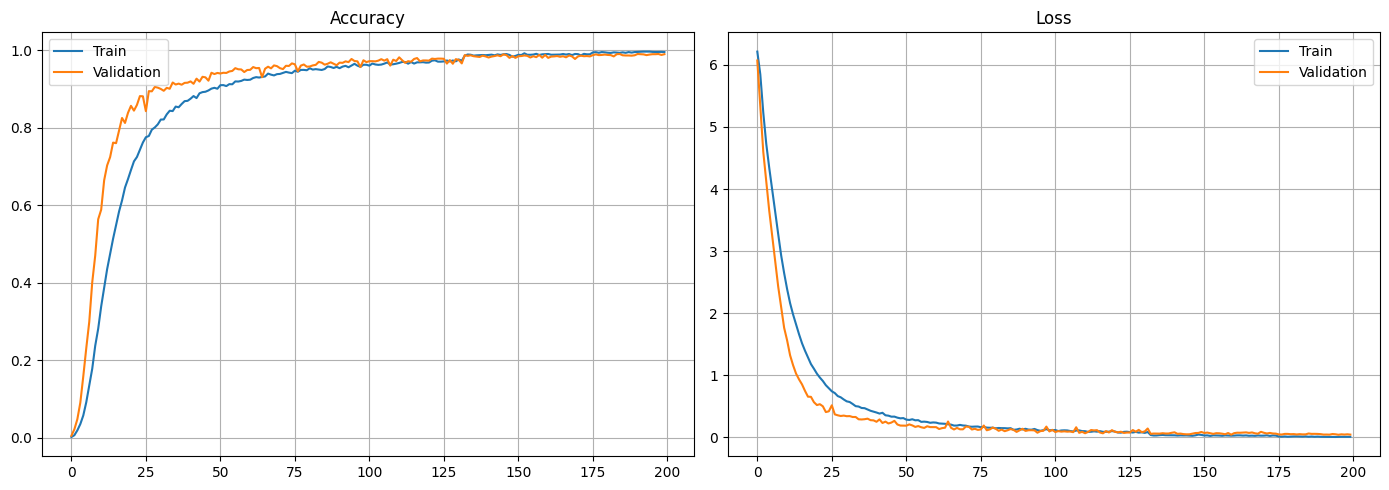

✅ تم الحفظ على Drive: /content/drive/MyDrive/KArSL_Model


In [11]:
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"\n🎯 دقة الاختبار: {test_acc * 100:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True)
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'training_curves.png'), dpi=150)
plt.show()

DRIVE_SAVE = '/content/drive/MyDrive/KArSL_Model'
os.makedirs(DRIVE_SAVE, exist_ok=True)
model.save(os.path.join(DRIVE_SAVE, 'final_model.keras'))
with open(os.path.join(DRIVE_SAVE, 'class_names.json'), 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(os.path.join(DRIVE_SAVE, 'training_history.json'), 'w') as f:
    json.dump(history_dict, f)
print(f"✅ تم الحفظ على Drive: {DRIVE_SAVE}")